In [1]:
from tqdm import tqdm
import pandas as pd
import numpy as np
import pickle

from instruments.stock import Stock
from instruments.option import Option, MetaOption
from instruments.ql_option import VanillaOption, DigitalOption
from instruments.portfolio import Portfolio
from instruments.option_interpolation import OptionInterpolator, OptionNumerical, create_option_value_and_greek_database

In [2]:
stock_price = 10
init_date = '2022-01-01'
risk_free_rate = 0
style = 'European'

strikes = np.arange(3.0, 16.6, 0.1)
vols = [0.01, 0.2, 0.3, 0.8]
stock_prices = strikes
tenors = np.arange(1, 31)

In [3]:
direction = 'Call'

db = create_option_value_and_greek_database(strikes, vols, tenors, stock_prices, risk_free_rate,
                                            DigitalOption, direction, style, f'Binary {direction}')

file_name = f'./option_database/Binary{direction}_rate_0.pkl'
with open(file_name, 'wb') as f:
    pickle.dump(db, f, pickle.HIGHEST_PROTOCOL)

100%|████████████████████████████████████████████████████████████████████████████████| 136/136 [19:49<00:00,  8.74s/it]


In [3]:
direction = 'Put'

db = create_option_value_and_greek_database(strikes, vols, tenors, stock_prices, risk_free_rate,
                                            VanillaOption, direction, style, 'American Put')

file_name = './option_database/AmericanPut_rate_0.pkl'
with open(file_name, 'wb') as f:
    pickle.dump(db, f, pickle.HIGHEST_PROTOCOL)

100%|█████████████████████████████████████████████████████████████████████████████| 131/131 [5:30:12<00:00, 151.24s/it]


In [5]:
with open(file_name, 'rb') as f:
    option_db = pickle.load(f)
            

## Compare the real value and interpolated value

In [6]:
option_db['data']['6.5']['0.30'].keys()

dict_keys(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90'])

In [38]:
op = OptionInterpolator(option_db['data'])

In [41]:
v = []
for s in np.arange(9.6, 9.7, 0.01):
    ops = Option(option_style, init_date, tenor, s, s, vol, risk_free_rate)
    v.append(ops.value)
    

In [42]:
import matplotlib.pyplot as plt

In [43]:
v

[0.5601318704540557,
 0.560715341152445,
 0.5612988118508344,
 0.5618822825492238,
 0.5624657532476132,
 0.5630492239460025,
 0.5636326946443937,
 0.5642161653427831,
 0.5647996360411724,
 0.5653831067395618]

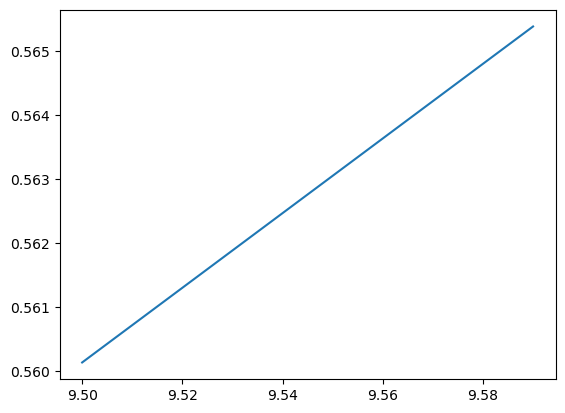

In [44]:
plt.plot(np.arange(9.5, 9.6, 0.01), v)

In [56]:
tenor = 90
# Link to stock object
strike = np.random.choice(np.arange(8, 13, 0.1))
stock = Stock(init_price=stock_price, mean=0, vol=vol, init_date=init_date)
option = AmericanOption(option_style, init_date, tenor, stock_price, strike, vol, risk_free_rate)
option_num = OptionNumerical(option_style, init_date, tenor, stock_price, strike, vol, risk_free_rate, 
                             option_interpolator=op)
stock.attach(option)
stock.attach(option_num)

# One year simulation
for _ in range(60):
    # When we call update method, stock price will move one step forward.
    stock.update()
    print(round((option.value - option_num.value)/option.value*100, 5),
          round((option.delta - option_num.delta)/option.delta*100, 5),
          round((option.gamma - option_num.gamma)/option.gamma*100, 5),
          round((option.vega - option_num.vega)/option.vega*100, 5))

-53.85539 -22.13722 7.61635 -35.99956
-62.78407 -28.20683 3.85547 -39.77975
-64.07721 -29.07822 3.30969 -38.04786
-72.97562 -35.22673 -0.64536 -44.14114
-78.59102 -39.14842 -3.22204 -46.50583
-81.89785 -41.37088 -4.63473 -53.28381
-75.7655 -37.08264 -1.821 -50.95563
-76.34074 -37.48892 -2.1074 -50.00842
-72.52238 -34.85492 -0.42435 -44.84492
-75.01393 -36.60431 -1.57281 -51.92156
-81.44529 -41.08055 -4.52506 -53.74293
-81.14329 -40.79568 -4.29174 -54.48208
-82.48493 -41.78254 -4.99805 -52.19378
-88.57772 -45.96538 -7.7179 -55.73281
-74.00323 -35.79242 -1.02999 -42.9727
-66.41287 -30.64439 2.19083 -43.64122
-58.61525 -25.23904 5.62657 -37.26768
-57.33177 -24.37889 6.14635 -39.05288
-55.02504 -22.79368 7.11098 -34.45691
-56.96677 -24.0828 6.34544 -32.07587
-62.0406 -27.54368 4.16687 -40.92538
-68.98708 -32.32306 1.11627 -40.19794
-74.34601 -35.93471 -1.15313 -42.62744
-62.84766 -28.06074 3.82702 -39.8067
-65.77914 -30.08834 2.52798 -44.78462
-77.04935 -37.83102 -2.45489 -48.99296
-67.841

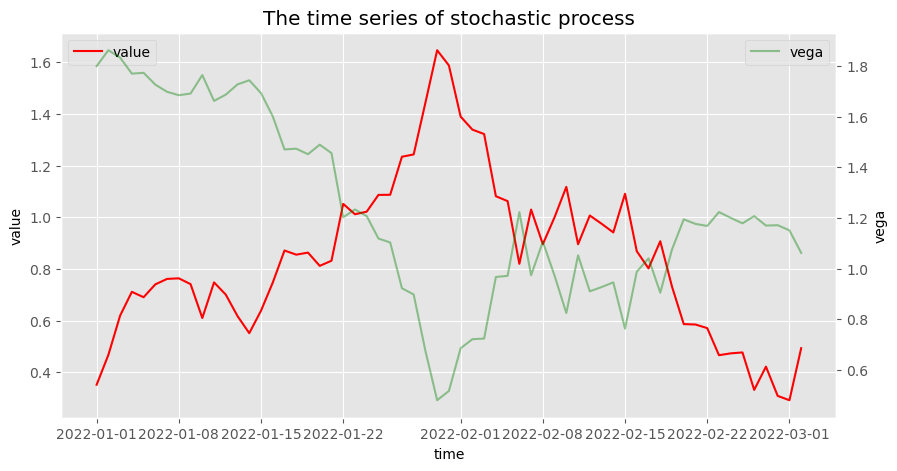

In [51]:
option.draw('value', 'vega')

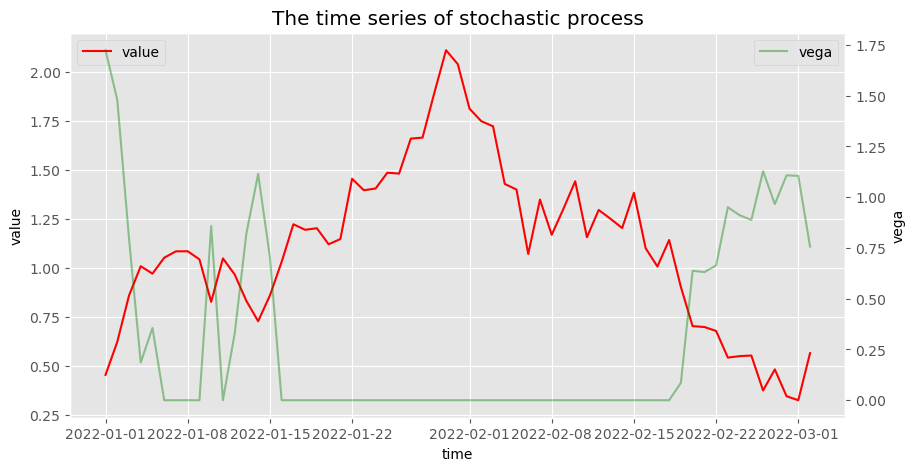

In [52]:
option_num.draw('value', 'vega')

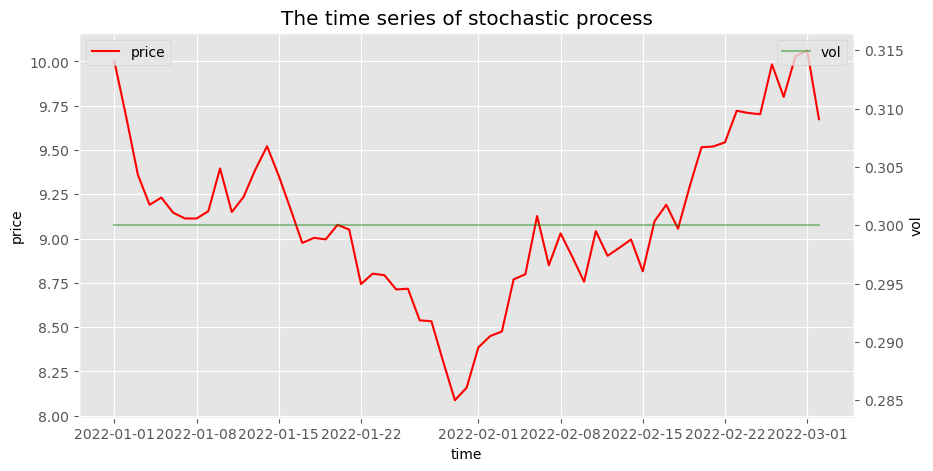

In [53]:
stock.draw('price', 'vol')

In [42]:
option.value

0.0011458454021073955

In [43]:
option_num.value

0.0011370483349505203

In [ ]:
sto